In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Import thư viện thành công!")

Import thư viện thành công!


In [2]:
PROJECT_ROOT = Path("..")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_features_labeled.csv"
)

df = pd.read_csv(DATA_PATH)

print("Kích thước dữ liệu:", df.shape)
print("\nCác cột:")
print(df.columns.tolist())

df.head()

Kích thước dữ liệu: (2658, 9)

Các cột:
['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems', 'Country', 'is_churn']


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalItems,Country,is_churn
0,12346.0,134,2,137.81,68.905000,20,18,United Kingdom,1
1,12347.0,55,4,2434.96,608.740000,90,1626,Iceland,0
2,12348.0,57,4,1388.40,347.100000,24,2488,Finland,0
3,12350.0,119,1,294.40,294.400000,16,196,Norway,1
4,12352.0,71,6,864.98,144.163333,36,374,Norway,0


In [3]:
print("Số giá trị thiếu:")
print(df.isnull().sum())

print("\nPhân bố nhãn:")
print(df["is_churn"].value_counts())

print("\nTỷ lệ nhãn (%):")
print(
    df["is_churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Số giá trị thiếu:
Customer ID       0
Recency           0
Frequency         0
Monetary          0
AvgOrderValue     0
UniqueProducts    0
TotalItems        0
Country           0
is_churn          0
dtype: int64

Phân bố nhãn:
is_churn
0    1854
1     804
Name: count, dtype: int64

Tỷ lệ nhãn (%):
is_churn
0    69.75
1    30.25
Name: proportion, dtype: float64


In [4]:
# Các biến đầu vào cho mô hình
feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "UniqueProducts",
    "TotalItems"
]

X = df[feature_cols].copy()
y = df["is_churn"].copy()

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

print("\nCác feature:")
print(X.columns.tolist())

X.head()

Kích thước X: (2658, 6)
Kích thước y: (2658,)

Các feature:
['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems']


,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalItems
0,134,2,137.81,68.905000,20,18
1,55,4,2434.96,608.740000,90,1626
2,57,4,1388.40,347.100000,24,2488
3,119,1,294.40,294.400000,16,196
4,71,6,864.98,144.163333,36,374


In [5]:
# Bước 1: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Bước 2: chia 80% còn lại thành train và validation
# Kết quả cuối: 60% train - 20% validation - 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1594, 6)
Validation: (532, 6)
Test: (532, 6)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Chuẩn hóa dữ liệu thành công!")
print("Train scaled:", X_train_scaled.shape)
print("Validation scaled:", X_val_scaled.shape)
print("Test scaled:", X_test_scaled.shape)

Chuẩn hóa dữ liệu thành công!
Train scaled: (1594, 6)
Validation scaled: (532, 6)
Test scaled: (532, 6)


In [7]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Đã huấn luyện Logistic Regression!")

Đã huấn luyện Logistic Regression!


In [8]:
y_val_pred = logistic_model.predict(
    X_val_scaled
)

y_val_prob = logistic_model.predict_proba(
    X_val_scaled
)[:, 1]

print("Dự đoán thành công!")

print("\n5 nhãn dự đoán đầu tiên:")
print(y_val_pred[:5])

print("\n5 xác suất churn đầu tiên:")
print(y_val_prob[:5])

Dự đoán thành công!

5 nhãn dự đoán đầu tiên:
[0 0 0 0 1]

5 xác suất churn đầu tiên:
[0.24163638 0.02689766 0.25429966 0.01243457 0.60572347]


In [9]:
accuracy = accuracy_score(
    y_val,
    y_val_pred
)

precision = precision_score(
    y_val,
    y_val_pred
)

recall = recall_score(
    y_val,
    y_val_pred
)

f1 = f1_score(
    y_val,
    y_val_pred
)

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

print("LOGISTIC REGRESSION - VALIDATION")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

LOGISTIC REGRESSION - VALIDATION
--------------------------------
Accuracy : 0.7256
Precision: 0.5581
Recall   : 0.4472
F1-score : 0.4966
ROC-AUC  : 0.7631


In [10]:
cm = confusion_matrix(
    y_val,
    y_val_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[314  57]
 [ 89  72]]


In [11]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=[
            "Không churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

 Không churn       0.78      0.85      0.81       371
       Churn       0.56      0.45      0.50       161

    accuracy                           0.73       532
   macro avg       0.67      0.65      0.65       532
weighted avg       0.71      0.73      0.72       532



In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Đã huấn luyện Random Forest!")

Đã huấn luyện Random Forest!


In [13]:
rf_val_pred = rf_model.predict(
    X_val
)

rf_val_prob = rf_model.predict_proba(
    X_val
)[:, 1]

print("Random Forest dự đoán thành công!")

print("\n5 nhãn đầu tiên:")
print(rf_val_pred[:5])

print("\n5 xác suất churn đầu tiên:")
print(rf_val_prob[:5])

Random Forest dự đoán thành công!

5 nhãn đầu tiên:
[0 0 0 0 1]

5 xác suất churn đầu tiên:
[0.125 0.045 0.105 0.045 0.705]


In [14]:
rf_accuracy = accuracy_score(
    y_val,
    rf_val_pred
)

rf_precision = precision_score(
    y_val,
    rf_val_pred
)

rf_recall = recall_score(
    y_val,
    rf_val_pred
)

rf_f1 = f1_score(
    y_val,
    rf_val_pred
)

rf_roc_auc = roc_auc_score(
    y_val,
    rf_val_prob
)

print("RANDOM FOREST - VALIDATION")
print("--------------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

RANDOM FOREST - VALIDATION
--------------------------------
Accuracy : 0.6955
Precision: 0.4973
Recall   : 0.5652
F1-score : 0.5291
ROC-AUC  : 0.7490


In [15]:
rf_cm = confusion_matrix(
    y_val,
    rf_val_pred
)

print("Random Forest - Confusion Matrix:")
print(rf_cm)

Random Forest - Confusion Matrix:
[[279  92]
 [ 70  91]]


In [16]:
print(
    classification_report(
        y_val,
        rf_val_pred,
        target_names=[
            "Không churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

 Không churn       0.80      0.75      0.78       371
       Churn       0.50      0.57      0.53       161

    accuracy                           0.70       532
   macro avg       0.65      0.66      0.65       532
weighted avg       0.71      0.70      0.70       532



In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1-score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7256,0.5581,0.4472,0.4966,0.7631
1,Random Forest,0.6955,0.4973,0.5652,0.5291,0.7490


In [18]:
from xgboost import XGBClassifier

print("Import XGBoost thành công!")

Import XGBoost thành công!


In [19]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

print("Đã huấn luyện XGBoost!")

Đã huấn luyện XGBoost!


In [20]:
xgb_val_pred = xgb_model.predict(
    X_val
)

xgb_val_prob = xgb_model.predict_proba(
    X_val
)[:, 1]

print("XGBoost dự đoán thành công!")

XGBoost dự đoán thành công!


In [21]:
xgb_accuracy = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_precision = precision_score(
    y_val,
    xgb_val_pred
)

xgb_recall = recall_score(
    y_val,
    xgb_val_pred
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_pred
)

xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_prob
)

print("XGBOOST - VALIDATION")
print("--------------------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBOOST - VALIDATION
--------------------------------
Accuracy : 0.7049
Precision: 0.5145
Recall   : 0.4410
F1-score : 0.4749
ROC-AUC  : 0.7552


In [22]:
xgb_cm = confusion_matrix(
    y_val,
    xgb_val_pred
)

print("XGBoost - Confusion Matrix:")
print(xgb_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        xgb_val_pred,
        target_names=[
            "Không churn",
            "Churn"
        ]
    )
)

XGBoost - Confusion Matrix:
[[304  67]
 [ 90  71]]

Classification Report:
              precision    recall  f1-score   support

 Không churn       0.77      0.82      0.79       371
       Churn       0.51      0.44      0.47       161

    accuracy                           0.70       532
   macro avg       0.64      0.63      0.63       532
weighted avg       0.69      0.70      0.70       532



In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1-score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7256,0.5581,0.4472,0.4966,0.7631
1,Random Forest,0.6955,0.4973,0.5652,0.5291,0.7490
2,XGBoost,0.7049,0.5145,0.4410,0.4749,0.7552


In [24]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, y_pred_threshold),
        "Precision": precision_score(y_val, y_pred_threshold),
        "Recall": recall_score(y_val, y_pred_threshold),
        "F1-score": f1_score(y_val, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.30,0.6711,0.4743,0.8012,0.5958
1,0.35,0.7030,0.5064,0.7391,0.6010
2,0.40,0.7124,0.5196,0.6584,0.5808
3,0.45,0.7350,0.5595,0.5839,0.5714
4,0.50,0.7256,0.5581,0.4472,0.4966
5,0.55,0.7143,0.5529,0.2919,0.3821
6,0.60,0.7030,0.5405,0.1242,0.2020


In [25]:
best_row = threshold_df.loc[
    threshold_df["F1-score"].idxmax()
]

print("Threshold tốt nhất theo F1:")
print(best_row.round(4))

Threshold tốt nhất theo F1:
Threshold    0.3500
Accuracy     0.7030
Precision    0.5064
Recall       0.7391
F1-score     0.6010
Name: 1, dtype: float64


In [26]:
best_threshold = best_row["Threshold"]

logistic_val_pred_best = (
    y_val_prob >= best_threshold
).astype(int)

print("Threshold được chọn:", best_threshold)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        logistic_val_pred_best
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        logistic_val_pred_best,
        target_names=["Không churn", "Churn"]
    )
)

Threshold được chọn: 0.35

Confusion Matrix:
[[255 116]
 [ 42 119]]

Classification Report:
              precision    recall  f1-score   support

 Không churn       0.86      0.69      0.76       371
       Churn       0.51      0.74      0.60       161

    accuracy                           0.70       532
   macro avg       0.68      0.71      0.68       532
weighted avg       0.75      0.70      0.71       532



In [27]:
rf_configs = [
    {
        "name": "RF_1",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "name": "RF_2",
        "n_estimators": 300,
        "max_depth": 8,
        "min_samples_leaf": 2
    },
    {
        "name": "RF_3",
        "n_estimators": 300,
        "max_depth": 6,
        "min_samples_leaf": 4
    }
]

rf_tuning_results = []

for config in rf_configs:

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    rf_tuning_results.append({
        "Model": config["name"],
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1-score": f1_score(y_val, pred),
        "ROC-AUC": roc_auc_score(y_val, prob)
    })

rf_tuning_df = pd.DataFrame(rf_tuning_results)

rf_tuning_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,RF_1,0.6955,0.4973,0.5652,0.5291,0.7490
1,RF_2,0.7030,0.5067,0.7019,0.5885,0.7771
2,RF_3,0.6898,0.4918,0.7453,0.5926,0.7791


In [28]:
best_rf_row = rf_tuning_df.loc[
    rf_tuning_df["F1-score"].idxmax()
]

print("Random Forest tốt nhất:")
print(best_rf_row)

Random Forest tốt nhất:
Model            RF_3
Accuracy      0.68985
Precision    0.491803
Recall       0.745342
F1-score     0.592593
ROC-AUC      0.779076
Name: 2, dtype: object


In [29]:
xgb_configs = [
    {
        "name": "XGB_1",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05
    },
    {
        "name": "XGB_2",
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03
    },
    {
        "name": "XGB_3",
        "n_estimators": 150,
        "max_depth": 3,
        "learning_rate": 0.10
    }
]

xgb_tuning_results = []

for config in xgb_configs:

    model = XGBClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    xgb_tuning_results.append({
        "Model": config["name"],
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1-score": f1_score(y_val, pred),
        "ROC-AUC": roc_auc_score(y_val, prob)
    })

xgb_tuning_df = pd.DataFrame(xgb_tuning_results)

xgb_tuning_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGB_1,0.7049,0.5145,0.4410,0.4749,0.7552
1,XGB_2,0.7350,0.5714,0.4969,0.5316,0.7675
2,XGB_3,0.7105,0.5252,0.4534,0.4867,0.7585


In [30]:
best_xgb_row = xgb_tuning_df.loc[
    xgb_tuning_df["F1-score"].idxmax()
]

print("XGBoost tốt nhất:")
print(best_xgb_row)

XGBoost tốt nhất:
Model           XGB_2
Accuracy     0.734962
Precision    0.571429
Recall       0.496894
F1-score     0.531561
ROC-AUC      0.767499
Name: 1, dtype: object


In [31]:
final_validation = pd.DataFrame({
    "Model": [
        "Logistic Regression (threshold=0.35)",
        best_rf_row["Model"],
        best_xgb_row["Model"]
    ],

    "Accuracy": [
        accuracy_score(y_val, logistic_val_pred_best),
        best_rf_row["Accuracy"],
        best_xgb_row["Accuracy"]
    ],

    "Precision": [
        precision_score(y_val, logistic_val_pred_best),
        best_rf_row["Precision"],
        best_xgb_row["Precision"]
    ],

    "Recall": [
        recall_score(y_val, logistic_val_pred_best),
        best_rf_row["Recall"],
        best_xgb_row["Recall"]
    ],

    "F1-score": [
        f1_score(y_val, logistic_val_pred_best),
        best_rf_row["F1-score"],
        best_xgb_row["F1-score"]
    ],

    "ROC-AUC": [
        roc_auc,
        best_rf_row["ROC-AUC"],
        best_xgb_row["ROC-AUC"]
    ]
})

final_validation.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression (threshold=0.35),0.7030,0.5064,0.7391,0.6010,0.7631
1,RF_3,0.6898,0.4918,0.7453,0.5926,0.7791
2,XGB_2,0.7350,0.5714,0.4969,0.5316,0.7675


In [32]:
# Xác suất churn trên tập Test
test_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

# Sử dụng threshold đã chốt từ Validation
test_pred = (
    test_prob >= 0.35
).astype(int)

test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

print("LOGISTIC REGRESSION - FINAL TEST")
print("--------------------------------")
print(f"Threshold : 0.35")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")

LOGISTIC REGRESSION - FINAL TEST
--------------------------------
Threshold : 0.35
Accuracy  : 0.6898
Precision : 0.4915
Recall    : 0.7205
F1-score  : 0.5844
ROC-AUC   : 0.7679


In [33]:
test_cm = confusion_matrix(
    y_test,
    test_pred
)

print("FINAL TEST - CONFUSION MATRIX")
print(test_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Không churn",
            "Churn"
        ]
    )
)

FINAL TEST - CONFUSION MATRIX
[[251 120]
 [ 45 116]]

Classification Report:
              precision    recall  f1-score   support

 Không churn       0.85      0.68      0.75       371
       Churn       0.49      0.72      0.58       161

    accuracy                           0.69       532
   macro avg       0.67      0.70      0.67       532
weighted avg       0.74      0.69      0.70       532



In [34]:
validation_vs_test = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Test"
    ],
    "Accuracy": [
        accuracy_score(
            y_val,
            logistic_val_pred_best
        ),
        test_accuracy
    ],
    "Precision": [
        precision_score(
            y_val,
            logistic_val_pred_best
        ),
        test_precision
    ],
    "Recall": [
        recall_score(
            y_val,
            logistic_val_pred_best
        ),
        test_recall
    ],
    "F1-score": [
        f1_score(
            y_val,
            logistic_val_pred_best
        ),
        test_f1
    ],
    "ROC-AUC": [
        roc_auc,
        test_auc
    ]
})

validation_vs_test.round(4)

,Dataset,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Validation,0.7030,0.5064,0.7391,0.6010,0.7631
1,Test,0.6898,0.4915,0.7205,0.5844,0.7679


In [36]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": logistic_model.coef_[0]
})

coef_df["Abs_Coefficient"] = (
    coef_df["Coefficient"].abs()
)

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient,Abs_Coefficient
1,Frequency,-2.248912,2.248912
5,TotalItems,-1.199871,1.199871
4,UniqueProducts,-0.629847,0.629847
0,Recency,0.331700,0.331700
2,Monetary,-0.153081,0.153081
3,AvgOrderValue,0.018299,0.018299


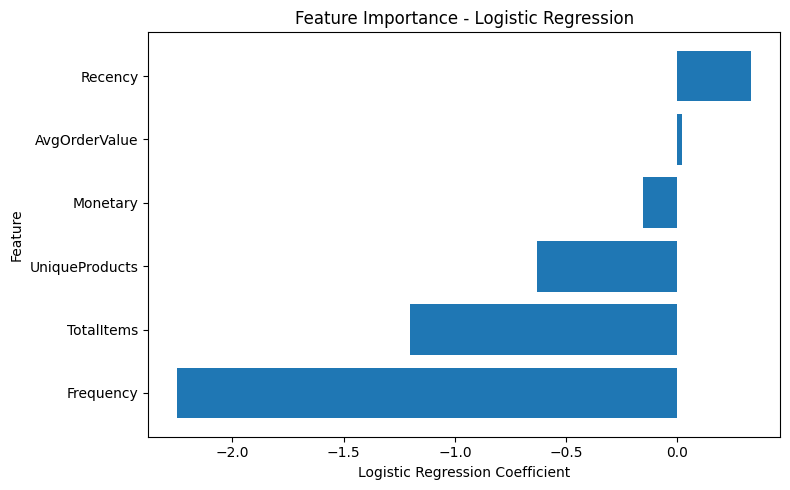

In [38]:
import matplotlib.pyplot as plt
plot_df = coef_df.sort_values(
    "Coefficient"
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance - Logistic Regression")

plt.tight_layout()
plt.show()

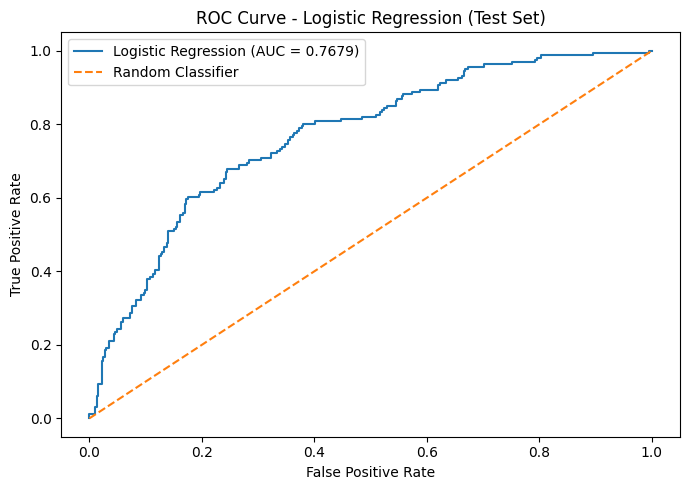

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Test Set)")
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    logistic_model,
    MODEL_DIR / "logistic_churn_model.pkl"
)

joblib.dump(
    scaler,
    MODEL_DIR / "scaler.pkl"
)

joblib.dump(
    {
        "threshold": 0.35,
        "features": feature_cols
    },
    MODEL_DIR / "model_config.pkl"
)

print("Đã lưu model thành công!")
print("Model:", MODEL_DIR / "logistic_churn_model.pkl")
print("Scaler:", MODEL_DIR / "scaler.pkl")
print("Config:", MODEL_DIR / "model_config.pkl")

Đã lưu model thành công!
Model: ..\models\logistic_churn_model.pkl
Scaler: ..\models\scaler.pkl
Config: ..\models\model_config.pkl


In [41]:
loaded_model = joblib.load(
    MODEL_DIR / "logistic_churn_model.pkl"
)

loaded_scaler = joblib.load(
    MODEL_DIR / "scaler.pkl"
)

loaded_config = joblib.load(
    MODEL_DIR / "model_config.pkl"
)

print("Load model thành công!")
print("Threshold:", loaded_config["threshold"])
print("Features:", loaded_config["features"])

Load model thành công!
Threshold: 0.35
Features: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems']
